# Hierarchical Clustering

## What is Hierarchical Clustering?

Hierarchical Clustering is an **unsupervised learning** method that groups similar data points into a hierarchy of clusters.

Instead of directly choosing the number of clusters first, it **builds a tree-like hierarchy of clusters**.

### Two main types

1. **Agglomerative Clustering** — Bottom-Up
2. **Divisive Clustering** — Top-Down

---

## 1. Agglomerative Clustering (Bottom-Up) : most commonly used

**Start:** Every data point is its own separate cluster.

Then:

1. Find the closest clusters.
2. Merge them into one cluster.
3. Again find the closest clusters.
4. Keep merging.
5. Continue until all points become one large cluster.

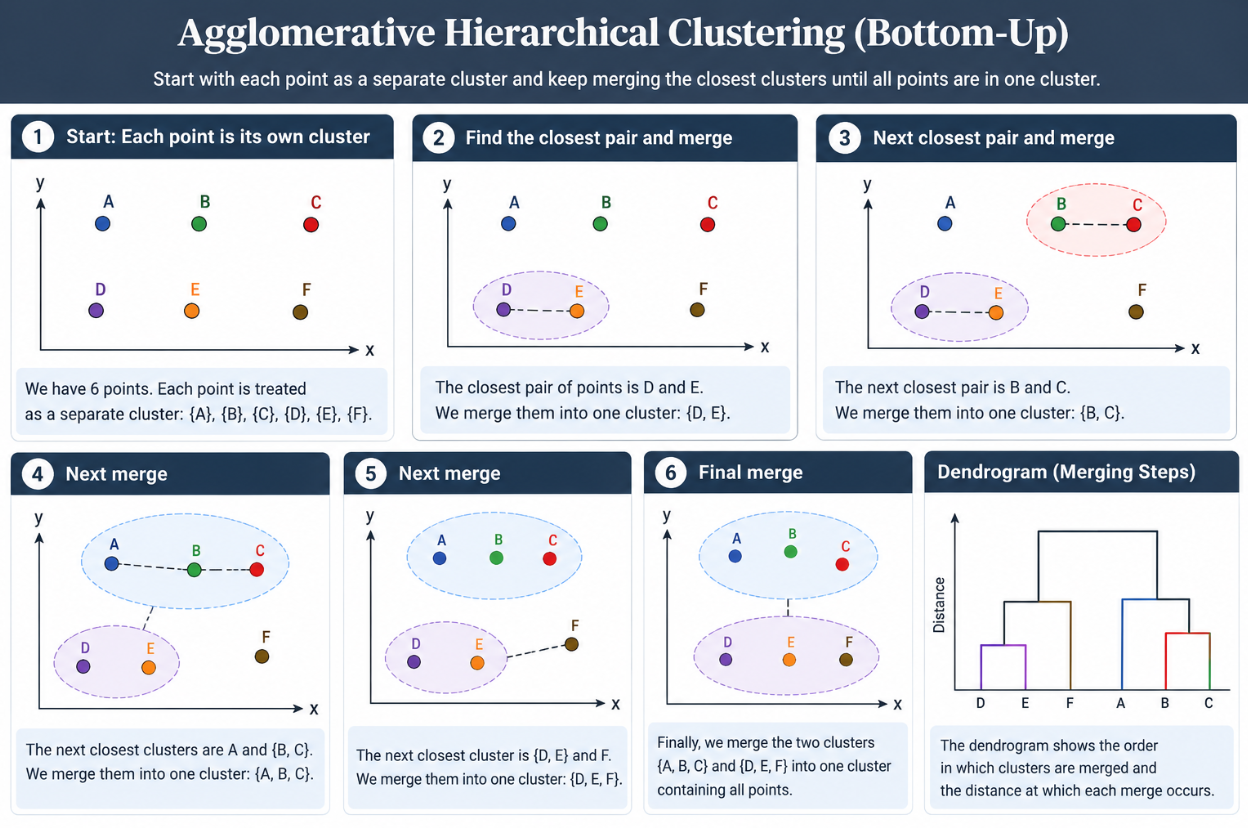

### Easy idea

**Many small clusters → fewer clusters → one big cluster**

So, it works **bottom-up**.

---

## 2. Divisive Clustering (Top-Down)

**Start:** All data points are in one large cluster.

Then:

1. Split the large cluster into smaller clusters.
2. Keep splitting the clusters.
3. Continue until the desired grouping is obtained.

### Easy idea

**One big cluster → smaller clusters → individual/smaller groups**

So, it works **top-down**.

---

## Key Difference

| Agglomerative | Divisive |
|---|---|
| Bottom-Up | Top-Down |
| Starts with each point as a separate cluster | Starts with all points in one cluster |
| Merges clusters | Splits clusters |
| Small → Big | Big → Small |



## Important Points

- We do **not need to specify the clusters beforehand** in the same way as K-Means.
- There are **no centroids** like in K-Means.


# Agglomerative Hierarchical Clustering Process

## Main idea

**Separate samples → calculate distances → find closest clusters → merge → recalculate distances → repeat**

---


## Distance Calculation

Suppose we have:

$$
P_1,\quad P_2,\quad P_3,\quad P_4,\quad P_5,\quad P_6
$$

Initially, every sample is its own cluster:

$$
\{P_1\},\quad
\{P_2\},\quad
\{P_3\},\quad
\{P_4\},\quad
\{P_5\},\quad
\{P_6\}
$$

So we initially have **6 clusters**.

---

## Euclidean Distance

For two points:

$$
P_i=(x_i,y_i)
$$

and

$$
P_j=(x_j,y_j)
$$

the Euclidean distance is:

$$
d(P_i,P_j)
=
\sqrt{(x_i-x_j)^2+(y_i-y_j)^2}
$$

### Example

Suppose:

$$
P_1=(2,3)
$$

and

$$
P_2=(5,7)
$$

Then:

$$
d(P_1,P_2)
=
\sqrt{(2-5)^2+(3-7)^2}
$$

$$
=\sqrt{9+16}
$$

$$
=\sqrt{25}
$$

$$
=5
$$

---

## Distance Matrix

The distances are stored in a **distance matrix**.

|  | $P_1$ | $P_2$ | $P_3$ | $P_4$ |
|---|---:|---:|---:|---:|
| **$P_1$** | 0 | $d(P_1,P_2)$ | $d(P_1,P_3)$ | $d(P_1,P_4)$ |
| **$P_2$** | $d(P_2,P_1)$ | 0 | $d(P_2,P_3)$ | $d(P_2,P_4)$ |
| **$P_3$** | $d(P_3,P_1)$ | $d(P_3,P_2)$ | 0 | $d(P_3,P_4)$ |
| **$P_4$** | $d(P_4,P_1)$ | $d(P_4,P_2)$ | $d(P_4,P_3)$ | 0 |

The diagonal is **0** because the distance from a point to itself is zero.

Also:

$$
d(P_i,P_j)=d(P_j,P_i)
$$

so the matrix is symmetric.

---

## Finding the Closest Pair

After calculating the distances, find the **smallest non-zero distance**.

For example, suppose:

$$
d(P_2,P_3)=2
$$

is the smallest distance.

Then the two clusters:

$$
\{P_2\}
\quad\text{and}\quad
\{P_3\}
$$

are merged:

$$
\{P_2\}+\{P_3\}
=
\{P_2,P_3\}
$$

The clusters now become:

$$
\{P_1\},\quad
\{P_2,P_3\},\quad
\{P_4\},\quad
\{P_5\},\quad
\{P_6\}
$$

So we now have **5 clusters**.

---

## After the Merge

Because $\{P_2,P_3\}$ is now a new cluster, we need to update the distances.

The way we calculate the distance between two **clusters** depends on the **linkage method** being used.

Common linkage methods are:

- **Single linkage**
- **Complete linkage**
- **Average linkage**

The lecture image shows the distance-matrix process but does not specify which linkage method is being used.

The process continues as:

$$
\boxed{
\text{Find closest}
\rightarrow
\text{Merge}
\rightarrow
\text{Update distances}
\rightarrow
\text{Repeat}
}
$$

---
---

## Dendrogram

Now that we understand the merging process, we can visualize those merges using a **dendrogram**.

### What is a Dendrogram?

A **dendrogram** is a tree-like diagram that shows:

- which samples/clusters were merged
- the order of the merges
- the distance at which each merge happened

So, it is basically a **visual record of the Agglomerative clustering process**.

---

### How is a Dendrogram Created?

Every time Agglomerative Clustering merges two clusters, we record that merge.

For example:

$$
P_1 \text{ and } P_2
$$

merge first at a small distance.

Then:

$$
P_3 \text{ joins } \{P_1,P_2\}
$$

at a larger distance.

The dendrogram represents these merges as branches.

The bottom contains the original samples:

$$
P_1,\quad P_2,\quad P_3,\quad P_4,\quad P_5
$$

The **height** at which two branches join represents the distance at which they were merged.

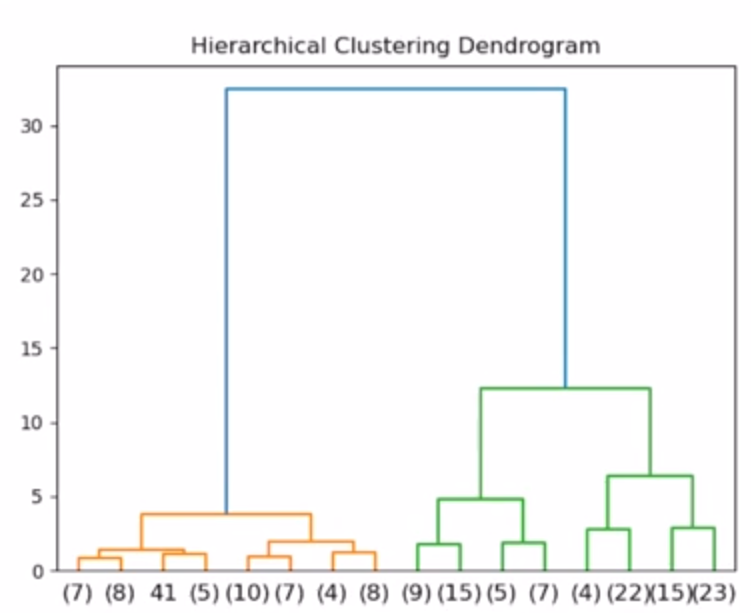

---

### Axes of a Dendrogram

**X-axis:** the samples/data points.

**Y-axis:** the distance (or dissimilarity) at which clusters were merged.

Therefore:

$$
\text{Higher merge}
\Rightarrow
\text{larger distance}
\Rightarrow
\text{more dissimilar clusters}
$$

---

## How Does It Help Choose the Number of Clusters?

We use the dendrogram to decide where to **cut** the hierarchy.

Draw a **horizontal line** across the dendrogram.

For example:

```text
Distance
   |
   |              |----------------|
   |              |                |
   |--------------|----------------|  ← horizontal cut
   |         |----|          |-----|
   |         |               |
   |     |---|---|       |---|---|
   |     |       |       |       |
   +----------------------------------→ Samples
```

The horizontal cut separates the data into groups.

### Counting the clusters

Count the number of branches that the horizontal line intersects.

That number is the selected number of clusters.

For example:

$$
\text{3 branches crossed}
\Rightarrow
\boxed{K=3}
$$

But how do we know where to draw the line?

---

## The "Longest Vertical Line" Idea

> **Look for the largest vertical gap between two consecutive merge levels.**

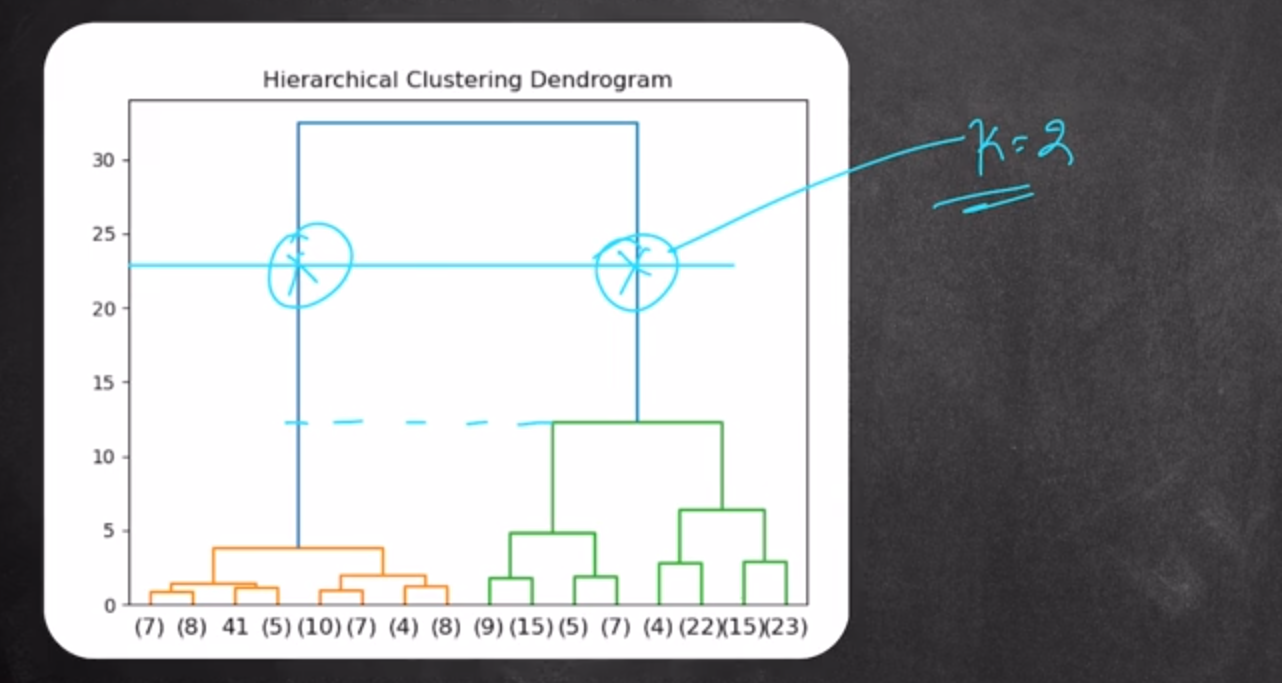

We do **not** choose a vertical line as the final cut.

Instead:

1. Look for a **large vertical gap** where no merge occurs.
2. Draw a **horizontal line through that gap**.
3. Count how many branches the horizontal line crosses.
4. That gives the suggested number of clusters.

### Why the largest gap?

Suppose the merge distances are:

$$
2,\quad 3,\quad 4,\quad 10
$$

There is a large jump:

$$
4 \rightarrow 10
$$

This suggests that the clusters were being merged at relatively small distances until the algorithm had to make a much larger-distance merge.

That large gap can indicate a natural separation between groups.

So we place the horizontal cut somewhere between:

$$
4 < \text{cut} < 10
$$

and count the resulting branches.

---

## Important Point

The dendrogram gives a **suggested** number of clusters. It is not an absolute rule.

A practical approach is:

$$
\boxed{
\text{Largest vertical gap}
\rightarrow
\text{Horizontal cut}
\rightarrow
\text{Count branches}
\rightarrow
K
}
$$

---

**Dendrogram = History of merges**

**Height = Merge distance**

**Large vertical gap = Possible cluster separation**

**Horizontal cut = Choose clusters**

**Branches after cut = Number of clusters**


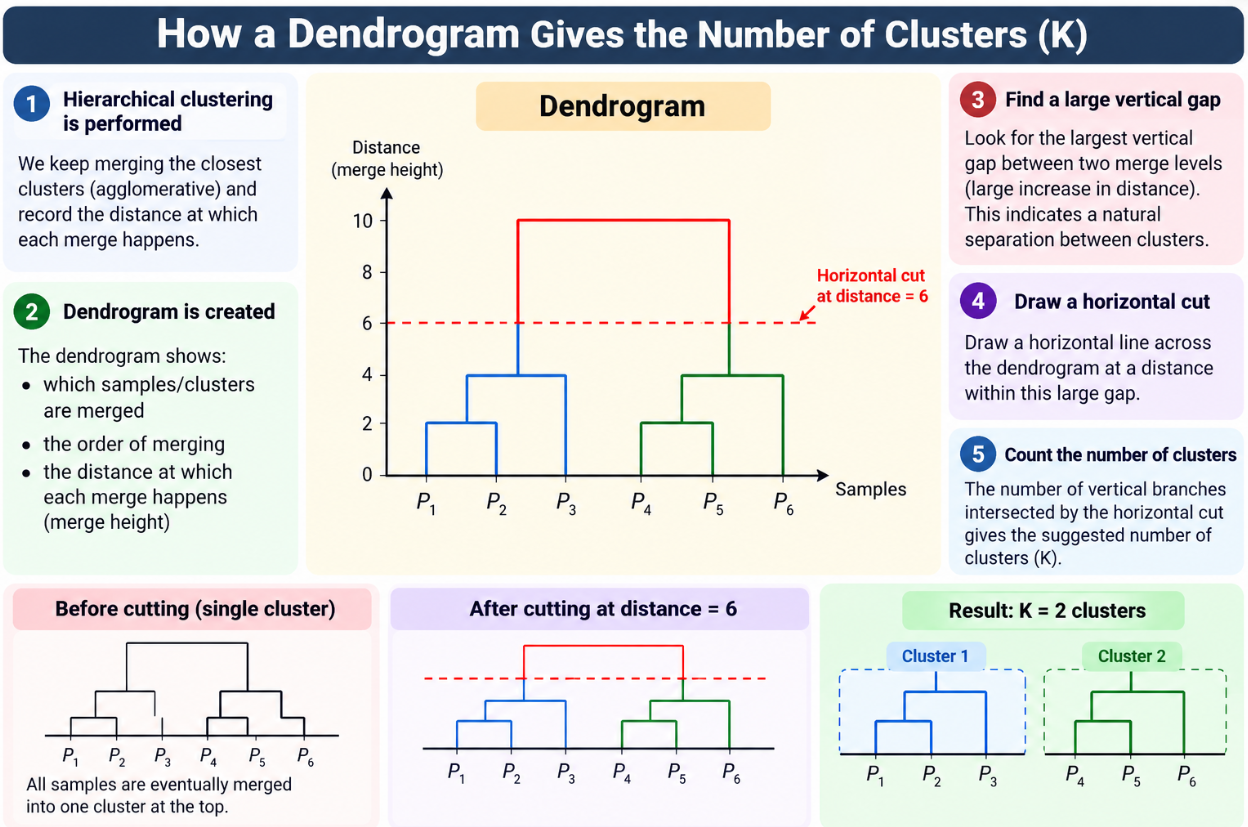

## K-Means vs Hierarchical Clustering

| **K-Means** | **Hierarchical Clustering** |
|---|---|
| **K-value:** Specified beforehand. | **K-value:** Can be decided later using the **dendrogram**. |
| Suitable for **large datasets**. | More suitable for **small to medium datasets**. |
| Time complexity: $O(nK)$ | Time complexity: $O(n^2)$ |
| **Faster** | **Slower** |

### 1. K-value

**K-Means:** Choose $K$ before running the algorithm.

Example:

$$
K=5
$$

**Hierarchical Clustering:** Build the hierarchy first, then use the **dendrogram** to decide a suitable $K$ by drawing a horizontal cut.

### 2. Dataset Size

**K-Means** is preferred for **large datasets** because it is faster.

**Hierarchical Clustering** is more suitable for **small to medium datasets** because its computation becomes expensive as the number of samples increases.

For example:

$$
n=10^5
$$

Hierarchical clustering can become expensive because of its $O(n^2)$ complexity.

### 3. Time Complexity

For K-Means:

$$
O(nK)
$$

where $n$ is the number of samples and $K$ is the number of clusters.

For Hierarchical Clustering:

$$
O(n^2)
$$

Therefore, hierarchical clustering generally becomes slower as $n$ increases.

### Easy Summary

$$
\boxed{\text{K-Means} \rightarrow \text{Large data + Faster + }K\text{ beforehand}}
$$

$$
\boxed{\text{Hierarchical} \rightarrow \text{Small/medium data + Slower + }K\text{ from dendrogram}}
$$
